<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/Lab_12(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(Library Initialization)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

(Dataset Loading)

In [ ]:
df = pd.read_csv('/content/student_data.csv')
print("="*65)
print("           STUDENT PERFORMANCE DATASET - OVERVIEW")
print("="*65)
print(f"  Total rows    : {df.shape[0]}")
print(f"  Total columns : {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")


numeric_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime',
                'failures', 'famrel', 'freetime', 'goout',
                'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


target_col = 'G3'

X_raw = df[numeric_cols].values
y     = df[target_col].values

print(f"\n  Features used : {numeric_cols}")
print(f"  Feature matrix shape X : {X_raw.shape}")
print(f"  Target vector  shape y : {y.shape}")

           STUDENT PERFORMANCE DATASET - OVERVIEW
  Total rows    : 395
  Total columns : 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

  Features used : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
  Feature matrix shape X : (395, 15)
  Target vector  shape y : (395,)


Task 1 (Feature Normalization)

In [ ]:
print("\n" + "="*65)
print("              TASK 1 – FEATURE NORMALIZATION")
print("="*65)


mu = np.mean(X_raw, axis=0)


sigma = np.std(X_raw, axis=0, ddof=1)


X_norm = (X_raw - mu) / sigma

print(f"\n  Feature means (µ)  : {np.round(mu, 3)}")
print(f"\n  Feature stds  (σ)  : {np.round(sigma, 3)}")
print(f"\n  Normalized X shape : {X_norm.shape}")
print(f"\n  Post-normalization mean (≈0): {np.round(np.mean(X_norm, axis=0), 5)}")
print(f"  Post-normalization std  (≈1): {np.round(np.std(X_norm, axis=0, ddof=1), 5)}")


              TASK 1 – FEATURE NORMALIZATION

  Feature means (µ)  : [16.696  2.749  2.522  1.448  2.035  0.334  3.944  3.235  3.109  1.481
  2.291  3.554  5.709 10.909 10.714]

  Feature stds  (σ)  : [1.276 1.095 1.088 0.698 0.839 0.744 0.897 0.999 1.113 0.891 1.288 1.39
 8.003 3.319 3.762]

  Normalized X shape : (395, 15)

  Post-normalization mean (≈0): [ 0.  0. -0.  0. -0.  0. -0.  0. -0.  0. -0.  0. -0.  0. -0.]
  Post-normalization std  (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Task 2 Convariance Matrix (Both Methods)

In [ ]:
print("\n" + "="*65)
print("             TASK 2 – THE COVARIANCE MATRIX")
print("="*65)

m = X_norm.shape[0]
n = X_norm.shape[1]
X_cov_loop = np.zeros((n, n))

for i in range(m):
    x_i = X_norm[i, :].reshape(n, 1)
    X_cov_loop += np.dot(x_i, x_i.T)

X_cov_loop = X_cov_loop / m

X_cov_matrix = np.dot(X_norm.T, X_norm) / m


are_equal = np.allclose(X_cov_loop, X_cov_matrix)

print(f"\n  Covariance matrix shape : {X_cov_matrix.shape}")
print(f"  Methods are equivalent  : {are_equal}")
print(f"\n  Covariance matrix (Matrix method) — top-left 5×5 block:\n")
print(np.round(X_cov_matrix[:5, :5], 4))


X_cov = X_cov_matrix


             TASK 2 – THE COVARIANCE MATRIX

  Covariance matrix shape : (15, 15)
  Methods are equivalent  : True

  Covariance matrix (Matrix method) — top-left 5×5 block:

[[ 0.9975 -0.1632 -0.163   0.0705 -0.0041]
 [-0.1632  0.9975  0.6219 -0.1712  0.0648]
 [-0.163   0.6219  0.9975 -0.1578 -0.0092]
 [ 0.0705 -0.1712 -0.1578  0.9975 -0.1007]
 [-0.0041  0.0648 -0.0092 -0.1007  0.9975]]


Task 3 (Eigen Decomposition)

In [ ]:
print("\n" + "="*65)
print("              TASK 3 – EIGEN DECOMPOSITION")
print("="*65)


eigenvalues, eigenvectors = np.linalg.eig(X_cov)


sort_idx   = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]


total_variance    = np.sum(eigenvalues)
explained_ratio   = eigenvalues / total_variance * 100   # percentage

print(f"\n  Eigenvalues (sorted) :\n  {np.round(eigenvalues, 4)}")
print(f"\n  Explained variance % :\n  {np.round(explained_ratio, 2)}")


cumulative_var = np.cumsum(explained_ratio)
print(f"\n  Cumulative variance % :\n  {np.round(cumulative_var, 2)}")


k = 4
U_full    = eigenvectors
U_reduced = U_full[:, :k]

# Project the normalized data onto the reduced eigenvector matrix
X_new = np.dot(X_norm, U_reduced)

print(f"\n  Full U matrix shape    : {U_full.shape}")
print(f"  Reduced U_k shape (k={k}): {U_reduced.shape}")


print(f"  Projected X_new shape  : {X_new.shape}")
print(f"\n  First 5 rows of projected data:\n{np.round(X_new[:5], 4)}")


              TASK 3 – EIGEN DECOMPOSITION

  Eigenvalues (sorted) :
  [2.828  1.9918 1.3798 1.2734 1.1663 0.9983 0.9264 0.8948 0.7671 0.7147
 0.6232 0.607  0.3623 0.2936 0.1353]

  Explained variance % :
  [18.9  13.31  9.22  8.51  7.8   6.67  6.19  5.98  5.13  4.78  4.17  4.06
  2.42  1.96  0.9 ]

  Cumulative variance % :
  [ 18.9   32.21  41.44  49.95  57.74  64.41  70.61  76.59  81.71  86.49
  90.66  94.71  97.13  99.1  100.  ]

  Full U matrix shape    : (15, 15)
  Reduced U_k shape (k=4): (15, 4)
  Projected X_new shape  : (395, 4)

  First 5 rows of projected data:
[[ 0.4882 -0.1827  2.2601 -0.7714]
 [ 1.313  -2.5845  0.6787  0.7529]
 [ 2.5322 -1.7336 -0.1765 -0.3546]
 [-2.6579 -0.6921  0.0212 -0.4316]
 [-0.2836 -0.7209  1.595   0.0859]]


Task 4 (Plots)


              TASK 4 – PROJECTION PLOTTING
  3-D features shape : (395, 3)
  2-D projection shape: (395, 2)
  Variance explained by 2 PCs: 95.08%


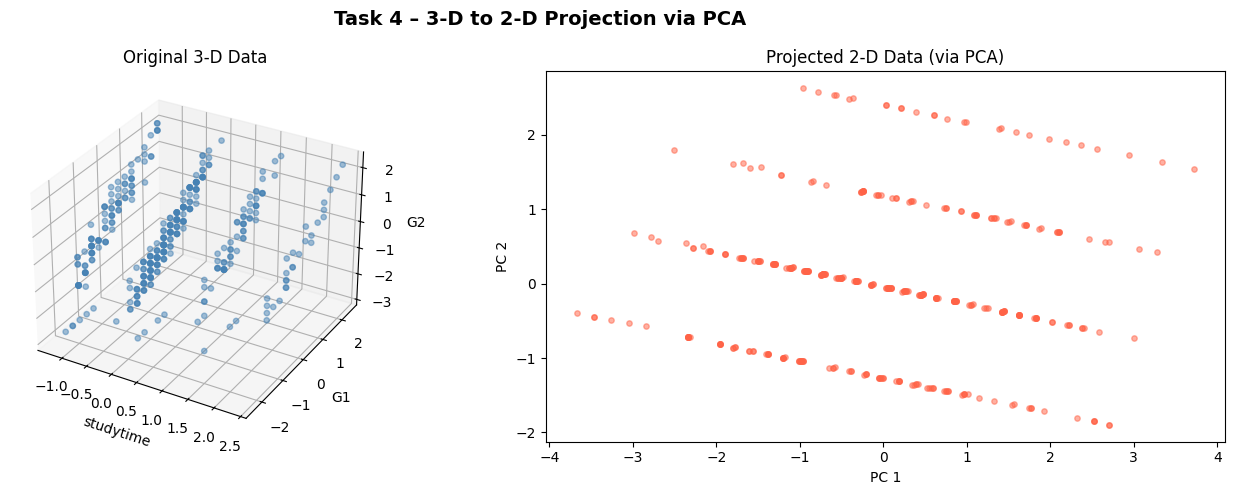

In [ ]:
print("\n" + "="*65)
print("              TASK 4 – PROJECTION PLOTTING")
print("="*65)



X_3d_raw = df[['studytime', 'G1', 'G2']].values


mu_3d    = np.mean(X_3d_raw, axis=0)
sigma_3d = np.std(X_3d_raw,  axis=0, ddof=1)
X_3d_norm = (X_3d_raw - mu_3d) / sigma_3d


X_3d_cov = np.dot(X_3d_norm.T, X_3d_norm) / m


evals_3d, evecs_3d = np.linalg.eig(X_3d_cov)
sort_3d  = np.argsort(evals_3d)[::-1]
evals_3d = evals_3d[sort_3d]
evecs_3d = evecs_3d[:, sort_3d]


U_3d_reduced = evecs_3d[:, :2]           # (3, 2)
X_2d_proj    = np.dot(X_3d_norm, U_3d_reduced)  # (m, 2)

print(f"  3-D features shape : {X_3d_norm.shape}")
print(f"  2-D projection shape: {X_2d_proj.shape}")
print(f"  Variance explained by 2 PCs: "
      f"{np.sum(evals_3d[:2]/np.sum(evals_3d)*100):.2f}%")


fig = plt.figure(figsize=(14, 5))
fig.suptitle("Task 4 – 3-D to 2-D Projection via PCA", fontsize=14, fontweight='bold')


ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_3d_norm[:, 0], X_3d_norm[:, 1], X_3d_norm[:, 2],
            c='steelblue', alpha=0.5, s=15)
ax1.set_xlabel('studytime'); ax1.set_ylabel('G1'); ax1.set_zlabel('G2')
ax1.set_title('Original 3-D Data')

ax2 = fig.add_subplot(122)
ax2.scatter(X_2d_proj[:, 0], X_2d_proj[:, 1], c='tomato', alpha=0.5, s=15)
ax2.set_xlabel('PC 1'); ax2.set_ylabel('PC 2')
ax2.set_title('Projected 2-D Data (via PCA)')

plt.tight_layout()


Task 5 (PCA Comparison With Linear Regression)


         TASK 5 – PCA FOR SUPERVISED LEARNING

  [Original 15 features]
    Features  : 15
    Train MSE : 3.1792
    Val   MSE : 4.5038

  [PCA k=2 features]
    Features  : 2
    Train MSE : 10.2302
    Val   MSE : 10.3206

  [PCA k=4 features]
    Features  : 4
    Train MSE : 5.0219
    Val   MSE : 6.1445

  [PCA k=6 features]
    Features  : 6
    Train MSE : 4.6829
    Val   MSE : 5.3733

  [PCA k=8 features]
    Features  : 8
    Train MSE : 4.6164
    Val   MSE : 5.0803

  [PCA k=10 features]
    Features  : 10
    Train MSE : 4.5337
    Val   MSE : 5.2757

  [PCA k=12 features]
    Features  : 12
    Train MSE : 3.9002
    Val   MSE : 5.0067


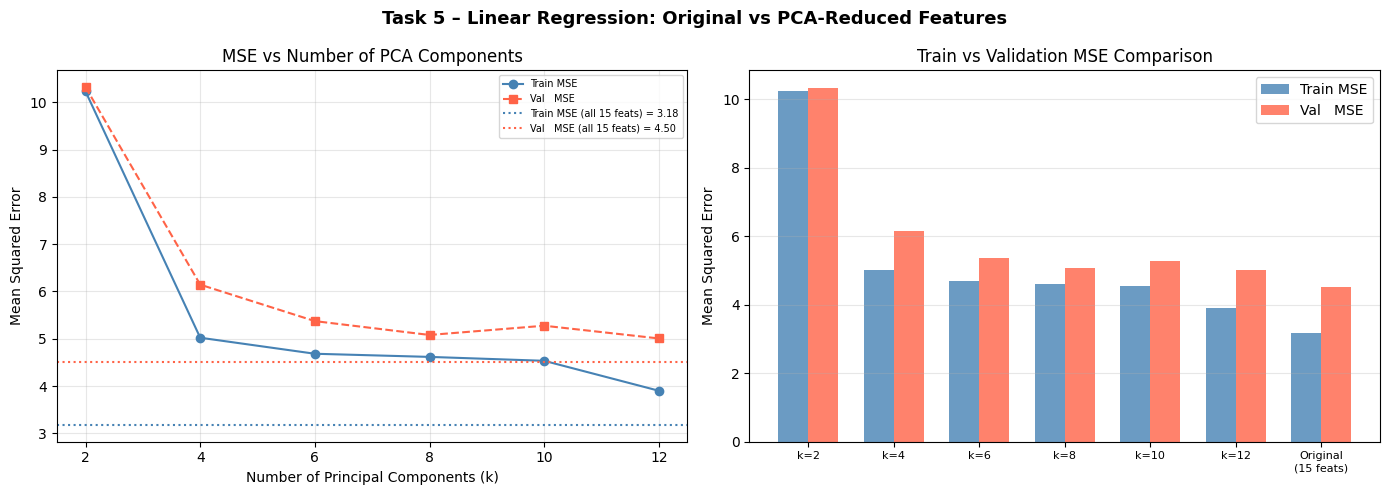

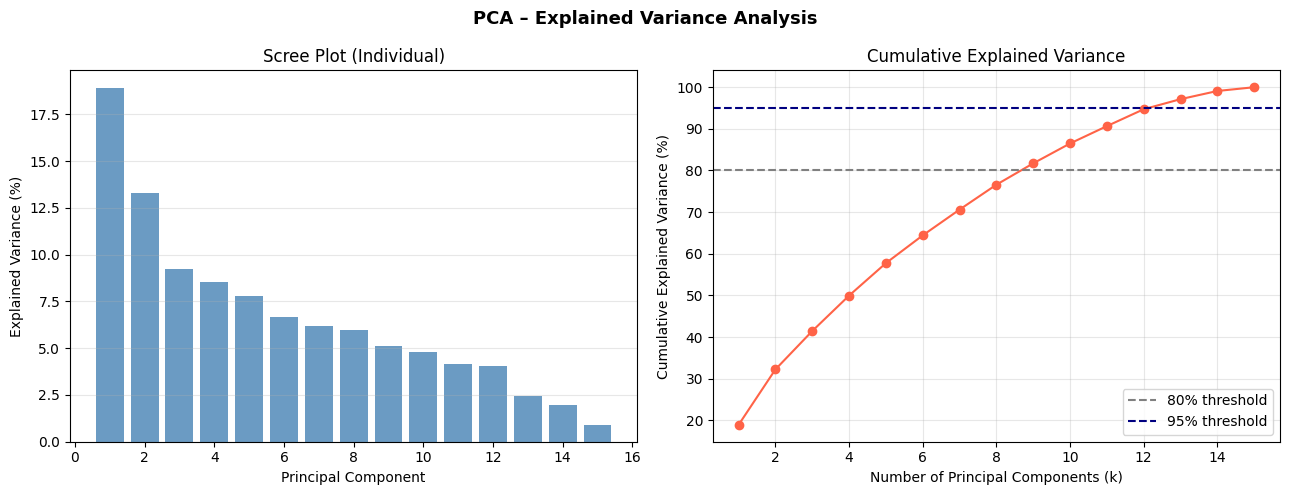

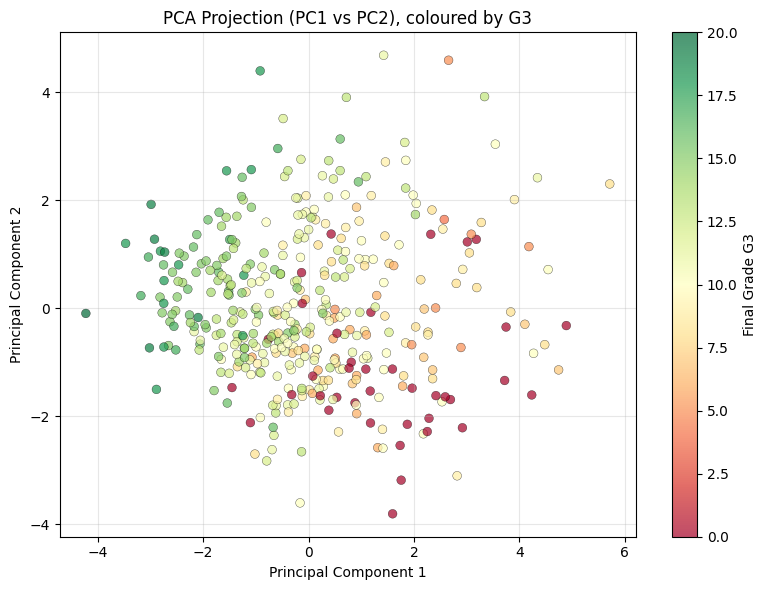

In [ ]:
print("\n" + "="*65)
print("         TASK 5 – PCA FOR SUPERVISED LEARNING")
print("="*65)


def run_linear_regression(X_data, y_data, label=""):
    """
    Split data 80/20, fit LinearRegression, return train/val MSE.
    """
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    train_mse = mean_squared_error(y_tr,  model.predict(X_tr))
    val_mse   = mean_squared_error(y_val, model.predict(X_val))

    print(f"\n  [{label}]")
    print(f"    Features  : {X_data.shape[1]}")
    print(f"    Train MSE : {train_mse:.4f}")
    print(f"    Val   MSE : {val_mse:.4f}")
    return train_mse, val_mse


train_mse_orig, val_mse_orig = run_linear_regression(
    X_norm, y, label="Original 15 features")


k_values         = [2, 4, 6, 8, 10, 12]
train_mse_list   = []
val_mse_list     = []

for ki in k_values:
    U_ki   = U_full[:, :ki]
    X_ki   = np.dot(X_norm, U_ki)         # project to ki dimensions
    tr_mse, vl_mse = run_linear_regression(
        X_ki, y, label=f"PCA k={ki} features")
    train_mse_list.append(tr_mse)
    val_mse_list.append(vl_mse)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 5 – Linear Regression: Original vs PCA-Reduced Features",
             fontsize=13, fontweight='bold')

# Left: loss vs k
ax = axes[0]
ax.plot(k_values, train_mse_list, 'o-', color='steelblue',  label='Train MSE')
ax.plot(k_values, val_mse_list,   's--', color='tomato',    label='Val   MSE')
ax.axhline(train_mse_orig, color='steelblue',  linestyle=':', linewidth=1.5,
           label=f'Train MSE (all 15 feats) = {train_mse_orig:.2f}')
ax.axhline(val_mse_orig,   color='tomato',     linestyle=':', linewidth=1.5,
           label=f'Val   MSE (all 15 feats) = {val_mse_orig:.2f}')
ax.set_xlabel('Number of Principal Components (k)')
ax.set_ylabel('Mean Squared Error')
ax.set_title('MSE vs Number of PCA Components')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Right: bar chart comparison
ax2 = axes[1]
categories = [f'k={ki}' for ki in k_values] + ['Original\n(15 feats)']
train_bars = train_mse_list + [train_mse_orig]
val_bars   = val_mse_list   + [val_mse_orig]
x = np.arange(len(categories))
w = 0.35
ax2.bar(x - w/2, train_bars, w, label='Train MSE', color='steelblue', alpha=0.8)
ax2.bar(x + w/2, val_bars,   w, label='Val   MSE', color='tomato',    alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=8)
ax2.set_ylabel('Mean Squared Error')
ax2.set_title('Train vs Validation MSE Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()



# =============================================================================
# ████████████████  BONUS – SCREE PLOT (Explained Variance)  █████████████████
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PCA – Explained Variance Analysis", fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(range(1, n+1), explained_ratio, color='steelblue', alpha=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot (Individual)')
ax.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
ax2.plot(range(1, n+1), cumulative_var, 'o-', color='tomato')
ax2.axhline(80, color='gray', linestyle='--', label='80% threshold')
ax2.axhline(95, color='navy', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Principal Components (k)')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()

# =============================================================================
# ████████████  BONUS – 2-D PCA SCATTER (Coloured by G3)  ████████████████████
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_new[:, 0], X_new[:, 1], c=y, cmap='RdYlGn',
                alpha=0.7, edgecolors='k', linewidths=0.3, s=40)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Final Grade G3')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA Projection (PC1 vs PC2), coloured by G3')
ax.grid(True, alpha=0.3)
plt.tight_layout()


